In [ ]:
import numpy as np
import torch
import scipy
import k3d
from tqdm import tqdm
# import ot
# from lib.SinkhornNP import SolveOT
import os
import pandas as pd
from misc.torchot import *
from misc.ulam import *
import matplotlib.pyplot as plt
from scipy.stats import special_ortho_group
import matplotlib.cm as cm
dev = torch.device('cuda')

In [2]:
class LinOp:
    def __init__(self, M):
        self.M = M
        self.shape = np.array(M.shape)
        self.dtype = np.float64
    def _matvec(self, v):
        return (self.M @ torch.tensor(v, device = dev)).cpu()
    @property
    def matvec(self):
        return self._matvec
    # @property
    # def shape(self):
    #     return self.M.shape


In [3]:
class RandomThiloFunctionClass:
    def __init__(self, Dim, mode_num,damp, R,rotation = True,Fourier_coef = None):
        self.Dim = Dim
        self.mode_num = mode_num
        self.damp = damp
        self.R = R
        if Fourier_coef:
            self.Fourier_coef = Fourier_coef
        else:
            self.Fourier_coef = torch.randn(size = (2,mode_num,Dim), device = dev)
        self.rotation = rotation
        self.Rot = torch.tensor(special_ortho_group.rvs(self.Dim),device = dev,dtype=torch.float32)

    def __call__(self, xgrid):
        d = self.Dim - 2
        mode_num = self.mode_num
        Fourier_coef = self.Fourier_coef
        R = self.R
        damp = self.damp
        xx = damp * torch.sin(torch.arange(1,mode_num+1, device = dev)[:,None] * 2 * torch.pi * xgrid[None,:])/((torch.arange(1,mode_num+1, device = dev)[:,None]))
        yy = damp * torch.cos(torch.arange(1,mode_num+1, device = dev)[:,None] * 2 * torch.pi * xgrid[None,:])/((torch.arange(1,mode_num+1, device = dev)[:,None]))
        pts = (Fourier_coef[0][:,None,:] * xx[:,:,None] + Fourier_coef[1][:,None,:] * yy[:,:,None]).sum(0)
        x1 = R * torch.sin(xgrid * 2 * torch.pi)
        y1 = R * torch.cos(xgrid * 2 * torch.pi)
        main_dim = torch.stack([x1,y1]).T
        Pt = torch.zeros(size = (xgrid.shape[0], d+2), device = dev)
        Pt[:,0:2] = main_dim
        Pt[:,0:2] += .2*pts[:,0:2]
        Pt[:,2:] += pts[:,2:]
        # if d > 0:
        #     Pt[:,2:] = pts[:,:]
        if self.rotation:
            return Pt@self.Rot
        return Pt

In [4]:
C = RandomThiloFunctionClass(Dim = 4,mode_num = 10,damp = .3,R = 1.5,rotation=0)


In [5]:
Npts = 500
sft = 1/5
std = .1
x = torch.rand(Npts,device = dev)
y = (x + sft)%1
xx = C(x)
yy = C(y)
xx += std * torch.randn_like(xx,device = dev)
yy += std * torch.randn_like(yy,device = dev)

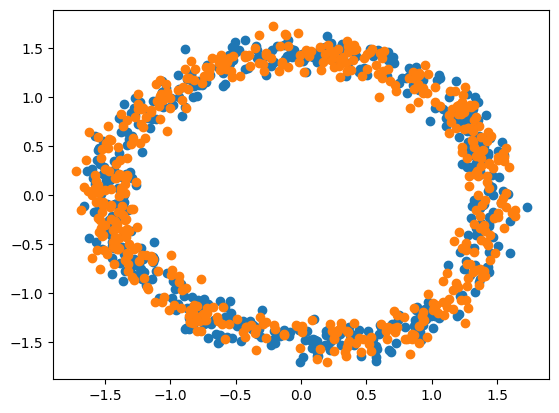

In [6]:
plt.scatter(xx.cpu()[:,0], xx.cpu()[:,1])
plt.scatter(yy.cpu()[:,0], yy.cpu()[:,1])
# plt.ylim(0,1)
# plt.xlim(0,1)

In [7]:
# plot = k3d.plot()
# plot += k3d.points(positions = np.random.rand(3))
# plot.display()

In [7]:
plot = k3d.plot()
plot += k3d.points(positions = xx[:,[0,1,3]].cpu().numpy(),
                   point_size = .1,
                   opacity= .8)
plot += k3d.points(positions = yy[:,[0,1,3]].cpu().numpy(),
                   point_size = .1,
                   color=0x00FF00,
                   opacity= .8)
plot.display()

Output()

In [ ]:
# C = RandomThiloFunctionClass(Dim = 10,mode_num = 10,damp = .3,R = 1.5,rotation=1)

In [ ]:
    # try:
    #     y = 1
    # except Exception as exp:
    #     print(excp)
    #     pass

In [14]:
ResOTO = {}
ResUlam = {}
Npts = 500
sft = 1/5
epsL = reversed(torch.linspace(1e-1,1e-2,10, device = dev))
C = RandomThiloFunctionClass(Dim = 10,mode_num = 10,damp = .3,R = 1.5,rotation=1)
stdL = [.05,.1,.2,.4]
for std in tqdm(stdL):
    Res = {
    'evec': [],
    'eval': []
    }
    Res2 = {
    'evec': [],
    'eval':[]
    }
    x = torch.rand(Npts,device = dev)
    y = (x + sft)%1
    xx = C(x)
    yy = C(y)
    xx += std * torch.randn_like(xx,device = dev)
    yy += std * torch.randn_like(yy,device = dev)
    CostX, alphaX, betaX = SolveEW2(xx, xx, epsL)
    CostY, alphaY, betaY = SolveEW2(xx, yy, epsL)
    for i in range(epsL.shape[0]):
        Tx = torch.exp((-torch.cdist(xx, xx)**2 + alphaX[i,:,None] + betaX[i,None,:])/epsL[i])/Npts
        Ty = torch.exp((-torch.cdist(xx, yy)**2 + alphaY[i,:,None] + betaY[i,None,:])/epsL[i])/Npts
        M = (Ty @ Tx)
        Op = scipy.sparse.linalg.aslinearoperator(LinOp(M))
        w, v = scipy.sparse.linalg.eigs(Op,10,maxiter=10000000, ncv = 200)
        Res['evec'].append(v)
        Res['eval'].append(w)
    ResOTO[std] = Res
    for eps in epsL:
        res_ulam = ulam(xx.cpu().numpy(),yy.cpu().numpy(),binsize=2*eps.item()**.5)
        w, v = scipy.sparse.linalg.eigs(res_ulam['T'],min(10,res_ulam['T'].shape[0]-2), ncv = 200)
        Res2['evec'].append(v)
        Res2['eval'].append(w)
    ResUlam[std] = Res2

 75%|███████▌  | 3/4 [00:54<00:19, 19.04s/it]

100%|██████████| 4/4 [01:37<00:00, 24.29s/it]


In [11]:
import pickle

In [ ]:
with open('ResUlam2.pkl', 'wb') as f:
    pickle.dump(ResUlam, f)

with open('ResOTO2.pkl', 'wb') as f:
    pickle.dump(ResOTO, f)

/local/jobs/u12153_11056802/ipykernel_3867629/4080866375.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0,i].scatter(ev.real, ev.imag, c = cm.viridis((len(epsL) - j)/len(epsL)))
/local/jobs/u12153_11056802/ipykernel_3867629/4080866375.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1,i].scatter(ev2.real, ev2.imag, c = cm.viridis((len(epsL) - j)/len(epsL)))


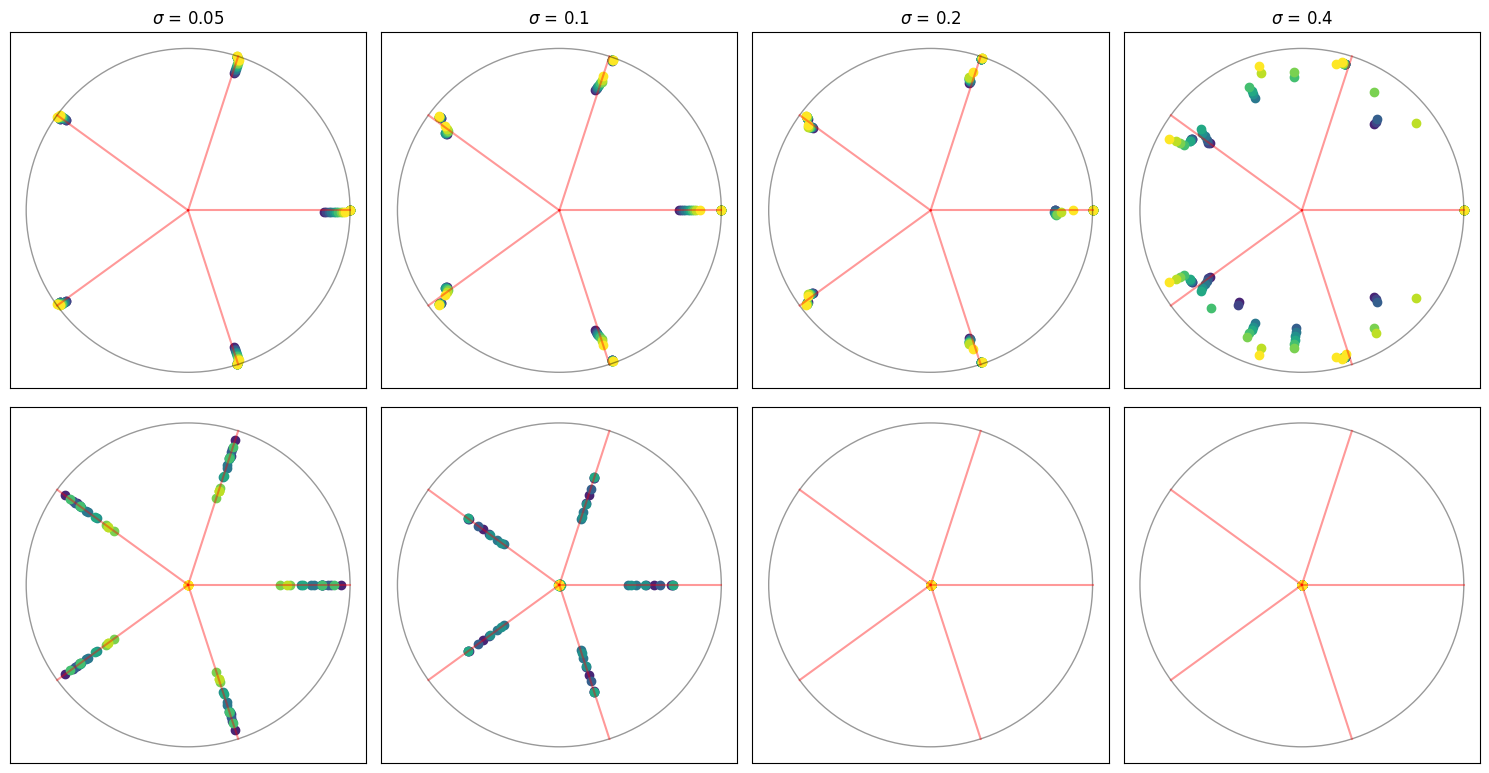

In [15]:
# ResOTO1 = ResOTO.copy()
# ResUlam1 = ResUlam.copy()
fig, ax = plt.subplots(ncols = len(stdL), nrows = 2, figsize = (15,8),sharex = True, sharey = True)

for i, std in enumerate(stdL):
    ax[0,i].set_title(f"$\sigma$ = {std}")
    for j in range(len(epsL))[::-1]:
        ev = ResOTO[std]['eval'][j]
        ev2 = ResUlam[std]['eval'][j]
        ax[0,i].scatter(ev.real, ev.imag, c = cm.viridis((len(epsL) - j)/len(epsL)))
        ax[1,i].scatter(ev2.real, ev2.imag, c = cm.viridis((len(epsL) - j)/len(epsL)))
for a in ax.ravel():
        
    for k in range(5):
        a.plot([0,np.cos(2*np.pi*k/5)],[0,np.sin(2*np.pi*k/5)], c = 'red', alpha = .4)
    circ = plt.Circle((0.0, 0.0), 1.0, facecolor='none', edgecolor='k', lw=1, alpha = .4)
    a.set_aspect('equal')
    a.set_xlim([-1.1,1.1])
    a.set_ylim([-1.1,1.1])
    a.set_xticks([])
    
    a.set_yticks([])
    a.add_patch(circ)
    a.set_ylabel('')

plt.tight_layout()

/local/jobs/u12153_10926564/ipykernel_454301/4119335062.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0,i].scatter(ev.real, ev.imag, c = cm.viridis((len(epsL) - j)/len(epsL)))
/local/jobs/u12153_10926564/ipykernel_454301/4119335062.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1,i].scatter(ev2.real, ev2.imag, c = cm.viridis((len(epsL) - j)/len(epsL)))


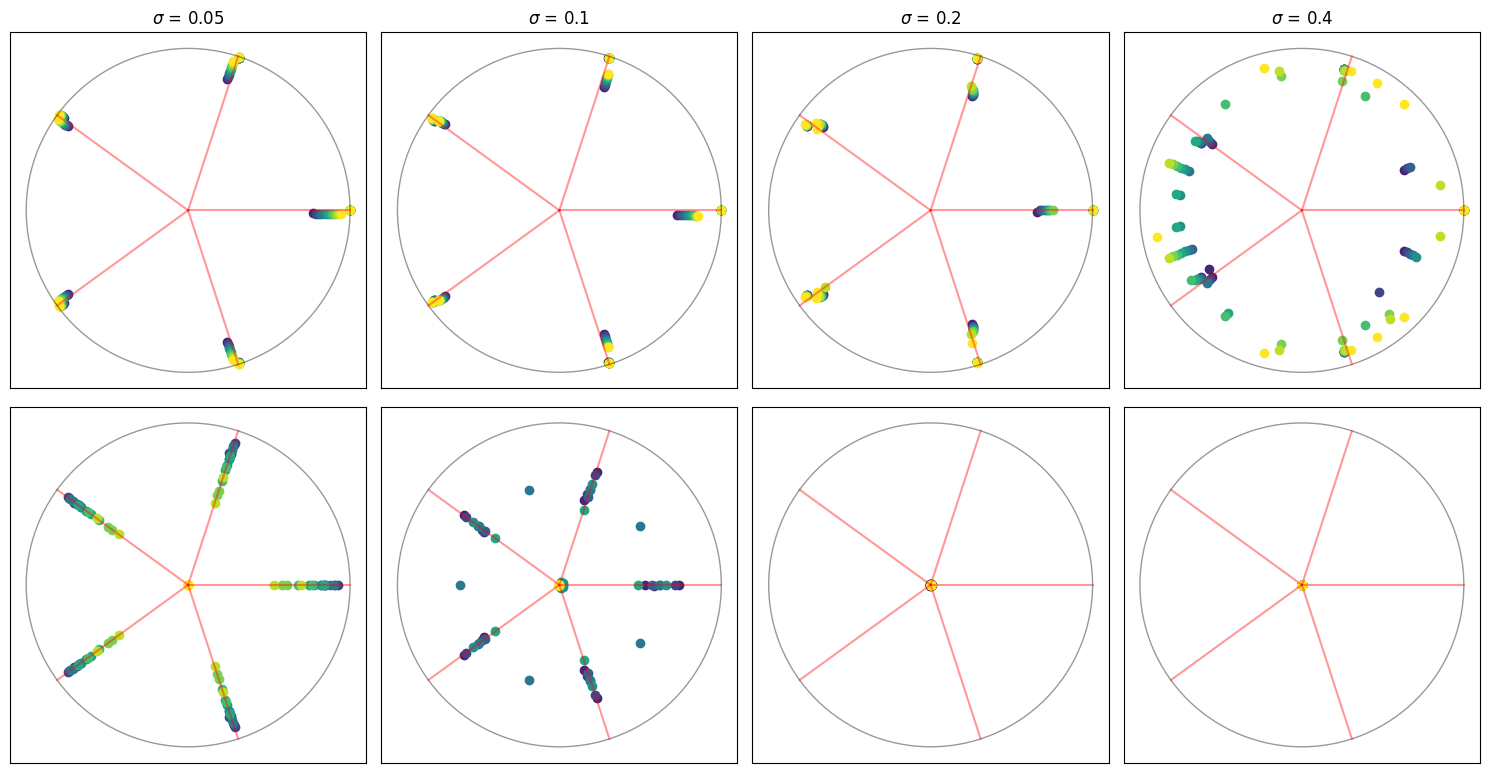

In [15]:
ResOTO1 = ResOTO.copy()
ResUlam1 = ResUlam.copy()
fig, ax = plt.subplots(ncols = len(stdL), nrows = 2, figsize = (15,8),sharex = True, sharey = True)

for i, std in enumerate(stdL):
    ax[0,i].set_title(f"$\sigma$ = {std}")
    for j in range(len(epsL))[::-1]:
        ev = ResOTO1[std]['eval'][j]
        ev2 = ResUlam1[std]['eval'][j]
        ax[0,i].scatter(ev.real, ev.imag, c = cm.viridis((len(epsL) - j)/len(epsL)))
        ax[1,i].scatter(ev2.real, ev2.imag, c = cm.viridis((len(epsL) - j)/len(epsL)))
for a in ax.ravel():
        
    for k in range(5):
        a.plot([0,np.cos(2*np.pi*k/5)],[0,np.sin(2*np.pi*k/5)], c = 'red', alpha = .4)
    circ = plt.Circle((0.0, 0.0), 1.0, facecolor='none', edgecolor='k', lw=1, alpha = .4)
    a.set_aspect('equal')
    a.set_xlim([-1.1,1.1])
    a.set_ylim([-1.1,1.1])
    a.set_xticks([])
    
    a.set_yticks([])
    a.add_patch(circ)
    a.set_ylabel('')

plt.tight_layout()

# plt.savefig('/user/bi/u12153/OTO/ulam_vs_OTO_dim100.pdf', format = 'pdf')

In [ ]:
i = 0
epsL = reversed(torch.linspace(1e-1,1e-2,20, device = dev))
CostX, alphaX, betaX = SolveEW2(xx, xx, epsL)
CostY, alphaY, betaY = SolveEW2(xx, yy, epsL)
ResOTO = {
    'evec': [],
    'eval': [],
    'std': []
}
for i in tqdm(range(epsL.shape[0])):
    Tx = torch.exp((-torch.cdist(xx, xx)**2 + alphaX[i,:,None] + betaX[i,None,:])/epsL[i])/Npts
    Ty = torch.exp((-torch.cdist(xx, yy)**2 + alphaY[i,:,None] + betaY[i,None,:])/epsL[i])/Npts
    M = (Ty @ Tx)
    Op = scipy.sparse.linalg.aslinearoperator(LinOp(M))
    w, v = scipy.sparse.linalg.eigs(Op,12,maxiter=100000)
    ResOTO['evec'].append(v)
    ResOTO['eval'].append(w)


100%|██████████| 20/20 [00:00<00:00, 63.40it/s]


/local/jobs/u12153_10803086/ipykernel_70367/2151584453.py:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(ev.real, ev.imag, c = cm.viridis((len(epsL) - i)/len(epsL)))


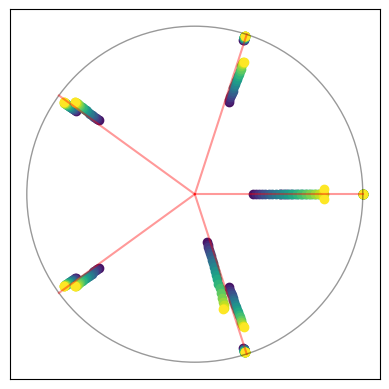

In [31]:
for k in range(5):
    plt.plot([0,np.cos(2*np.pi*k/5)],[0,np.sin(2*np.pi*k/5)], c = 'red', alpha = .4)
circ = plt.Circle((0,0),1, fill = False, alpha = .4)
# plt.plot([0,-np.cos(4*np.pi/5)],[0,np.sin(4*np.pi/5)], c = 'blue')
for i in range(len(epsL))[::-1]:
    ev = Res['eval'][i]
    plt.scatter(ev.real, ev.imag, c = cm.viridis((len(epsL) - i)/len(epsL)))
plt.gca().add_patch(circ)
plt.gca().set_aspect('equal')
plt.gca().set_xlim([-1.1,1.1])
plt.gca().set_ylim([-1.1,1.1])
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_ylabel('')
plt.show()

In [46]:
Res2 = {
    'evec': [],
    'eval':[]
}
for b in tqdm(range(2,8)):
    res_ulam = ulam(xx.cpu().numpy(),yy.cpu().numpy(),bincnt=b)
    w, v = scipy.sparse.linalg.eigs(res_ulam['T'],min(10,res_ulam['T'].shape[0]-2), ncv = 100)
    Res2['evec'].append(v)
    Res2['eval'].append(w)

100%|██████████| 6/6 [00:00<00:00, 53.12it/s]


/local/jobs/u12153_10803086/ipykernel_70367/2942551136.py:3: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(ev.real, ev.imag, c = cm.viridis(1 - i/6))


(-1.1, 1.1)

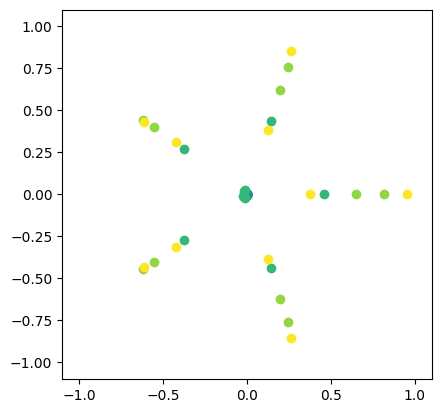

In [47]:
for i in range(6)[::-1]:
    ev = Res2['eval'][i]
    plt.scatter(ev.real, ev.imag, c = cm.viridis(1 - i/6))
plt.gca().set_aspect('equal')
plt.gca().set_xlim([-1.1,1.1])
plt.gca().set_ylim([-1.1,1.1])

In [ ]:
BL = range(3,8)
Res2 = {
    'evec': [],
    'eval':[]
}
x_normal = xx - xx.min()
x_normal = x_normal/x_normal.max()
y_normal = yy - yy.min()
y_normal = y_normal/y_normal.max()
for bins in tqdm(BL):
    HM =  (torch.hstack([x_normal,y_normal]) * bins)//1
    HM = HM.to(int)
    HM[torch.where(HM == bins)] = bins-1
    SA = scipy.sparse.coo_array((np.ones(Npts),HM.T.cpu().numpy()), [bins]*xx.shape[1]*2)
    SA.sum_duplicates()
    SA = SA.reshape(bins**xx.shape[1],-1)
    un, ind = np.unique(SA.coords,return_inverse=True)
    ind = ind.reshape(2,-1)
    SA = scipy.sparse.coo_array((SA.data,ind),[un.shape[0]]*2)
    print(bins, (SA > 0.01).sum())
    SA = SA/(SA.sum(0)[None,:])
    # SA /= np.sum(SA,axis=0,keepdims=True)
    # SA = np.nan_to_num(SA)
    # Op = scipy.sparse.linalg.aslinearoperator(LinOp(Mat))
    w, v = scipy.sparse.linalg.eigs(SA,min(10,SA.shape[0]-2))
    Res2['evec'].append(v)
    Res2['eval'].append(w)

i=0

  0%|          | 0/5 [00:00<?, ?it/s]/mnt/lustre-grete/projects/nhr_ni_starter_22625/env_jupyter/lib/python3.11/site-packages/scipy/sparse/_base.py:766: RuntimeWarning: divide by zero encountered in divide
  recip = np.true_divide(1., other)
100%|██████████| 5/5 [00:00<00:00, 36.47it/s]

3 242
4 293
5 547
6 662
7 799


/local/jobs/u12153_10727800/ipykernel_1174017/2059454094.py:3: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(ev.real, ev.imag, c = cm.viridis(1 - i/len(BL)))


(-1.1, 1.1)

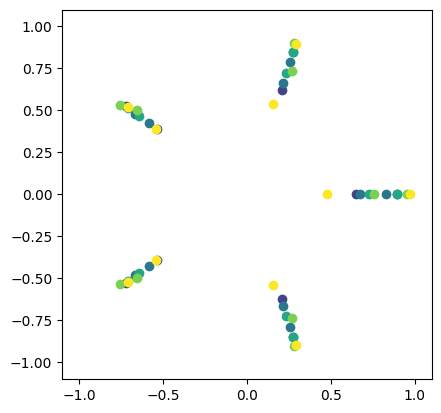

In [712]:
for i in range(len(BL))[::-1]:
    ev = Res2['eval'][i]
    plt.scatter(ev.real, ev.imag, c = cm.viridis(1 - i/len(BL)))
plt.gca().set_aspect('equal')
plt.gca().set_xlim([-1.1,1.1])
plt.gca().set_ylim([-1.1,1.1])


In [166]:
gd_size = 300
x = torch.linspace(0,1, gd_size, device = dev)[1:]
y = torch.linspace(0,1, gd_size, device = dev)[1:]
x,y = torch.meshgrid(x,y)
pts = torch.stack([x,y]).reshape(2,-1)

/mnt/lustre-grete/projects/nhr_ni_starter_22625/env_jupyter/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [167]:
def emb_torus(pts, R, r):
    u = pts[0,:] * torch.pi * 2
    v = pts[1,:] * torch.pi * 2
    x1 = R * torch.cos(u) + r * torch.cos(v) * torch.cos(u)
    x2 = R * torch.sin(u) + r * torch.cos(v) * torch.sin(u)
    x3 = r * torch.sin(v)
    return torch.stack([x1,x2,x3])

In [168]:
res = emb_torus(pts, 5, 2)
plot = k3d.plot()
plot += k3d.points(positions = res.cpu().T,
                   point_size = .2,
                   opacity= .1)
plot.display()

Output()

In [169]:
def sft_pts(pts, sft_x, sft_y):
    vec = torch.tensor([sft_x, sft_y], device = dev)
    return (pts + vec[:,None])%1

In [170]:
xx = torch.linspace(0,.1,20,device = dev)
yy = (-2 * xx + .4)%1
pt = torch.stack([xx, yy])

In [171]:
# plt.scatter(*pt.cpu())
# plt.scatter(*sft_pts(pt,.3,.4).cpu())
# plt.gca().set_aspect('equal')
# plt.gca().set_xlim([0,1])
# plt.gca().set_ylim([0,1])

In [172]:
N = 10000
sft_x = 1/10
sft_y = 0
x_cloud = torch.rand(size = (2,N), device = dev)
y_cloud = sft_pts(x_cloud, sft_x, sft_y)

In [173]:
R = 5
r = 2
x_emb = emb_torus(x_cloud, R, r)
y_emb = emb_torus(y_cloud, R, r)

In [174]:
res = emb_torus(pts, 5, 2)
plot = k3d.plot()
plot += k3d.points(positions = res.cpu().T,
                   point_size = .2,
                   opacity= .05)
plot += k3d.points(positions = x_emb.cpu().T,
                   point_size = .05, color = 0xFF0000)
plot += k3d.points(positions = y_emb.cpu().T,
                   point_size = .05, color = 0x00AF00)
plot.display()

Output()

In [175]:
epsL = reversed(torch.logspace(-1.5,1,20, device = dev))
CostX, alphaX, betaX = SolveEW2(x_emb.T, x_emb.T, epsL)


In [176]:
CostY, alphaY, betaY = SolveEW2(x_emb.T, y_emb.T, epsL)

In [8]:
class LinOp:
    def __init__(self, M):
        self.M = M
        self.shape = np.array(M.shape)
        self.dtype = np.float64
    def _matvec(self, v):
        return (self.M @ torch.tensor(v, device = dev)).cpu()
    @property
    def matvec(self):
        return self._matvec
    # @property
    # def shape(self):
    #     return self.M.shape


In [178]:
Res = {
    'evec': [],
    'eval':[]
}
for i in tqdm(range(epsL.shape[0])):
    Tx = torch.exp((-torch.cdist(x_emb.T, x_emb.T)**2 + alphaX[i,:,None] + betaX[i,None,:])/epsL[i])/N
    Ty = torch.exp((-torch.cdist(x_emb.T, y_emb.T)**2 + alphaY[i,:,None] + betaY[i,None,:])/epsL[i])/N
    M = (Ty @ Tx)
    Op = scipy.sparse.linalg.aslinearoperator(LinOp(M))
    w, v = scipy.sparse.linalg.eigs(Op,20,maxiter=100000)
    Res['evec'].append(v)
    Res['eval'].append(w)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:08<00:00,  2.28it/s]


In [179]:
i = 0

tensor(10., device='cuda:0')


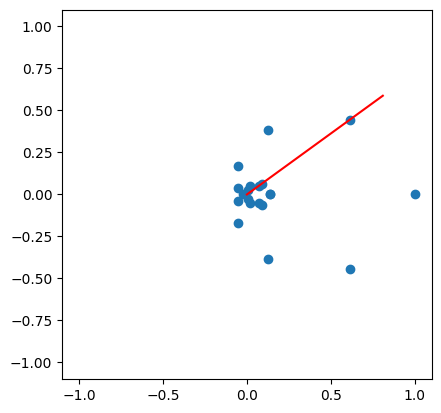

In [180]:

ev = Res['eval'][i]
plt.scatter(ev.real, ev.imag)
plt.plot([0,np.cos(2*np.pi/10)],[0,np.sin(2*np.pi/10)], c = 'red')
plt.gca().set_aspect('equal')
plt.gca().set_xlim([-1.1,1.1])
plt.gca().set_ylim([-1.1,1.1])
print(epsL[i])
i += 1

In [181]:
BL = range(3,10)
Res2 = {
    'evec': [],
    'eval':[]
}
for i in tqdm(range(len(BL))):
    EE = np.vstack([x_emb.cpu(),y_emb.cpu()]).T
    H = np.histogramdd(EE, bins = BL[i],density=True)
    Mat = H[0].reshape(BL[i]**3, BL[i]**3)
    Mat /= np.sum(Mat,axis=0,keepdims=True)
    Mat = np.nan_to_num(Mat)
    # Op = scipy.sparse.linalg.aslinearoperator(LinOp(Mat))
    w, v = scipy.sparse.linalg.eigs(Mat,20)
    Res2['evec'].append(v)
    Res2['eval'].append(w)

  0%|          | 0/7 [00:00<?, ?it/s]/local/jobs/u12153_10700401/ipykernel_646123/2989317581.py:10: RuntimeWarning: invalid value encountered in divide
  Mat /= np.sum(Mat,axis=0,keepdims=True)
100%|██████████| 7/7 [00:00<00:00, 13.79it/s]


In [183]:
EE.shape

(10000, 6)

In [341]:
i = 0

6


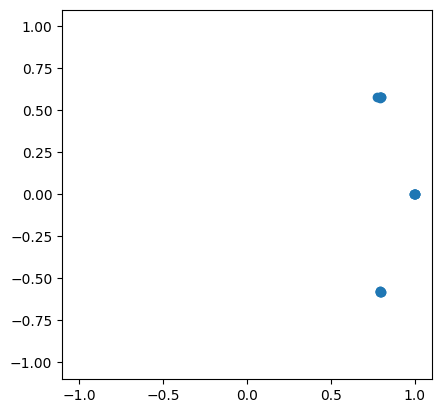

In [345]:

ev = Res2['eval'][i]
plt.scatter(ev.real, ev.imag)
plt.gca().set_aspect('equal')
plt.gca().set_xlim([-1.1,1.1])
plt.gca().set_ylim([-1.1,1.1])
print(BL[i])
i = (i+1)%len(BL)